## Tweets classification
#### 0 - Neutral
#### 1 - positive / encouraging
#### 2 - negative / decouraging

## Loading the data

In [ ]:
import pandas as pd
train_df = pd.read_excel("train.xlsx")
valid_df = pd.read_excel("valid.xlsx")
test_df  = pd.read_excel("test.xlsx")

train_df.shape, valid_df.shape, test_df.shape

((5701, 2), (1222, 2), (1222, 2))

train data rows : 5701 (~70%)

valid data rows : 1222 (~15%)

test data rows : 1222 (~15%)

In [ ]:
train_df["Label"].value_counts()


,count
Label,
0,2749
1,2005
2,947


## Model-1 : Tfidf tokenizer + MLP

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2,
    stop_words="english",
    norm="l2"
)

X_train = tfidf.fit_transform(train_df["Tweet"])
X_valid = tfidf.transform(valid_df["Tweet"])

y_train = train_df["Label"]
y_valid = valid_df["Label"]

X_train.shape, X_valid.shape

((5701, 11288), (1222, 11288))

In [ ]:
import torch
import numpy as np
X_train_dense = X_train.toarray()
X_train_tensor = torch.tensor(X_train_dense, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_valid_dense = X_valid.toarray()
X_valid_tensor = torch.tensor(X_valid_dense, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.long)

X_train_tensor.shape, y_train_tensor.shape

(torch.Size([5701, 11288]), torch.Size([5701]))

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False
)



In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
num_classes = 3
model = MLP(input_dim=11288, num_classes=num_classes)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
import torch
from sklearn.metrics import f1_score
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
num_epochs = 10
for epoch in range(num_epochs):

    # =========================
    # TRAINING PHASE
    # =========================
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Step 1: zero gradients
        optimizer.zero_grad()

        # Step 2: forward pass
        logits = model(X_batch)

        # Step 3: compute loss
        loss = criterion(logits, y_batch)

        # Step 4: backward pass
        loss.backward()

        # Step 5: update weights
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # =========================
    # VALIDATION PHASE
    # =========================
    model.eval()
    val_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # forward pass
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item()

            # predictions
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    avg_val_loss = val_loss / len(valid_loader)

    # =========================
    # MACRO F1 SCORE
    # =========================
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    val_macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    # =========================
    # LOGGING
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )


Epoch [1/10] | Train Loss: 0.9840 | Val Loss: 0.8743 | Val Macro F1: 0.4339
Epoch [2/10] | Train Loss: 0.6206 | Val Loss: 0.9419 | Val Macro F1: 0.5450
Epoch [3/10] | Train Loss: 0.2849 | Val Loss: 1.2615 | Val Macro F1: 0.5295
Epoch [4/10] | Train Loss: 0.1238 | Val Loss: 1.5389 | Val Macro F1: 0.5263
Epoch [5/10] | Train Loss: 0.0622 | Val Loss: 1.8115 | Val Macro F1: 0.5288
Epoch [6/10] | Train Loss: 0.0472 | Val Loss: 1.9380 | Val Macro F1: 0.5264
Epoch [7/10] | Train Loss: 0.0381 | Val Loss: 2.0546 | Val Macro F1: 0.5372
Epoch [8/10] | Train Loss: 0.0332 | Val Loss: 2.1603 | Val Macro F1: 0.5307
Epoch [9/10] | Train Loss: 0.0297 | Val Loss: 2.2257 | Val Macro F1: 0.5263
Epoch [10/10] | Train Loss: 0.0312 | Val Loss: 2.2320 | Val Macro F1: 0.5173


## Model 2 : Basic Tokenizer + MLP

In [ ]:

from collections import Counter

MAX_VOCAB = 20000
MAX_LEN = 50

counter = Counter()

for text in train_df["Tweet"]:
    counter.update(text.split())

vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

def encode(text):
    tokens = text.split()
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids
import torch

X_train = torch.tensor([encode(t) for t in train_df["Tweet"]])
y_train = torch.tensor(train_df["Label"].values)

X_valid = torch.tensor([encode(t) for t in valid_df["Tweet"]])
y_valid = torch.tensor(valid_df["Label"].values)
X_train.shape, y_train.shape

(torch.Size([5701, 50]), torch.Size([5701]))

In [ ]:
X_train[0]

tensor([  11,  712,    5,  291,   37,    6,  217,  271, 2450,   23,    5,   46,
          27,  237, 1078,  444,    8,  217,   11,    6,  739, 3388,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TweetDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64

train_ds = TweetDataset(X_train, y_train)
valid_ds = TweetDataset(X_valid, y_valid)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size)


In [ ]:
import torch.nn as nn

class MLPTextClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, num_classes=3):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=vocab["<pad>"]
        )

        self.fc1 = nn.Linear(emb_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        emb = self.embedding(x)          # (batch, seq_len, emb_dim)
        pooled = emb.mean(dim=1)         # mean pooling
        out = self.fc1(pooled)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLPTextClassifier(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


In [ ]:
import torch
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

num_epochs = 10

train_losses = []
val_losses = []
val_f1s = []

for epoch in range(num_epochs):

    # =======================
    # TRAINING
    # =======================
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # =======================
    # VALIDATION
    # =======================
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    val_macro_f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1s.append(val_macro_f1)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )


Epoch [1/10] | Train Loss: 1.0262 | Val Loss: 0.9981 | Val Macro F1: 0.3564
Epoch [2/10] | Train Loss: 0.9632 | Val Loss: 0.9642 | Val Macro F1: 0.3859
Epoch [3/10] | Train Loss: 0.9292 | Val Loss: 0.9423 | Val Macro F1: 0.3973
Epoch [4/10] | Train Loss: 0.8905 | Val Loss: 0.9316 | Val Macro F1: 0.4100
Epoch [5/10] | Train Loss: 0.8628 | Val Loss: 0.9143 | Val Macro F1: 0.4412
Epoch [6/10] | Train Loss: 0.8241 | Val Loss: 0.9031 | Val Macro F1: 0.4815
Epoch [7/10] | Train Loss: 0.7973 | Val Loss: 0.8970 | Val Macro F1: 0.5065
Epoch [8/10] | Train Loss: 0.7632 | Val Loss: 0.8894 | Val Macro F1: 0.5024
Epoch [9/10] | Train Loss: 0.7322 | Val Loss: 0.8878 | Val Macro F1: 0.4930
Epoch [10/10] | Train Loss: 0.6848 | Val Loss: 0.8920 | Val Macro F1: 0.5138


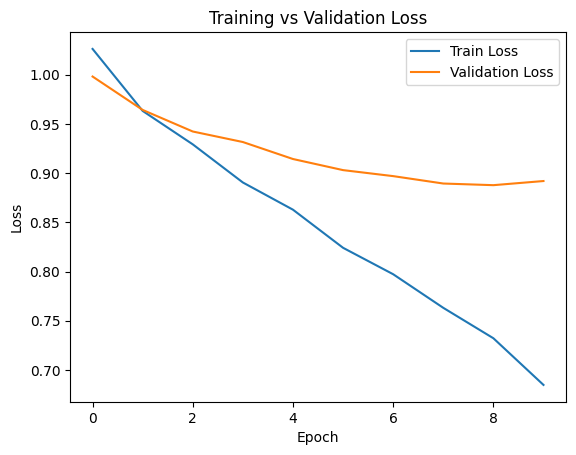

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


## Model 3 : Logistic regression + basic tokenizer

In [ ]:
import torch
import torch.nn as nn

class LogisticTextClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, num_classes=3):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=vocab["<pad>"]
        )
        self.fc = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        emb = self.embedding(x)          # (B, T, D)

        mask = (x != vocab["<pad>"]).unsqueeze(-1)
        emb = emb * mask
        pooled = emb.sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        logits = self.fc(pooled)
        return logits


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LogisticTextClassifier(
    vocab_size=len(vocab),
    emb_dim=128,
    num_classes=3
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


In [ ]:
import torch
from sklearn.metrics import f1_score

num_epochs = 30

train_losses = []
val_losses = []
val_f1s = []

for epoch in range(num_epochs):

    # =====================
    # TRAIN
    # =====================
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # =====================
    # VALIDATION
    # =====================
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    val_macro_f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1s.append(val_macro_f1)

    # =====================
    # LOG
    # =====================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )


Epoch [1/30] | Train Loss: 0.8121 | Val Loss: 0.9044 | Val Macro F1: 0.4772
Epoch [2/30] | Train Loss: 0.7904 | Val Loss: 0.8968 | Val Macro F1: 0.4844
Epoch [3/30] | Train Loss: 0.7762 | Val Loss: 0.8904 | Val Macro F1: 0.4977
Epoch [4/30] | Train Loss: 0.7613 | Val Loss: 0.8855 | Val Macro F1: 0.4954
Epoch [5/30] | Train Loss: 0.7421 | Val Loss: 0.8812 | Val Macro F1: 0.5045
Epoch [6/30] | Train Loss: 0.7268 | Val Loss: 0.8770 | Val Macro F1: 0.5199
Epoch [7/30] | Train Loss: 0.7085 | Val Loss: 0.8743 | Val Macro F1: 0.5175
Epoch [8/30] | Train Loss: 0.6959 | Val Loss: 0.8723 | Val Macro F1: 0.5402
Epoch [9/30] | Train Loss: 0.6832 | Val Loss: 0.8703 | Val Macro F1: 0.5366
Epoch [10/30] | Train Loss: 0.6695 | Val Loss: 0.8687 | Val Macro F1: 0.5418
Epoch [11/30] | Train Loss: 0.6534 | Val Loss: 0.8678 | Val Macro F1: 0.5474
Epoch [12/30] | Train Loss: 0.6457 | Val Loss: 0.8671 | Val Macro F1: 0.5435
Epoch [13/30] | Train Loss: 0.6258 | Val Loss: 0.8667 | Val Macro F1: 0.5463
Epoch [1

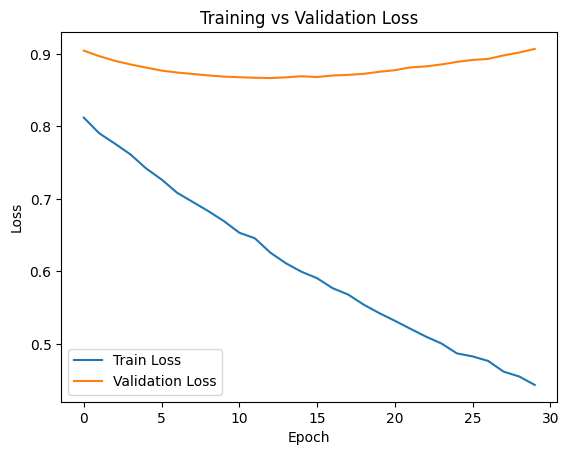

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()
